<h1 style="color: green;">Home Task</h1>

<h3 style="color: green;">Brest cancer dataset</h3>

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn import tree
import graphviz
import os
os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'
cancer = load_breast_cancer()
X, y, labels, features = cancer.data, cancer.target, cancer.target_names, cancer.feature_names
print ('labels:',labels)
print ('features:', features)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

labels: ['malignant' 'benign']
features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


<h3 style="color: green;">DecisionTree</h3>

train accuracy= 97.418%
test accuracy= 95.804%


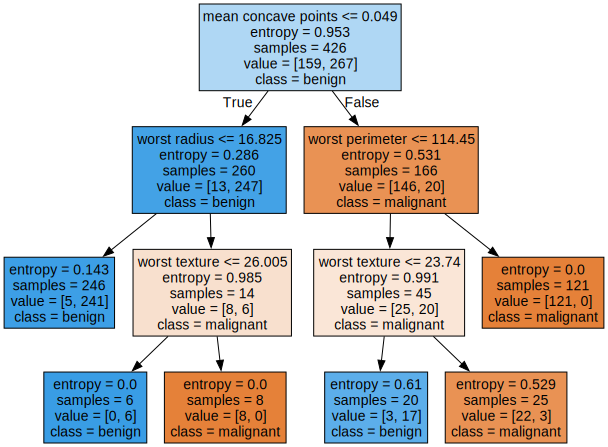

In [2]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE
clf = tree.DecisionTreeClassifier(criterion = 'entropy', random_state = 20, max_leaf_nodes = 6, max_depth=6)
clf.fit(X_train, y_train)
# END_CODE 
print("train accuracy= {:.3%}".format(clf.score(X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test, y_test)))

graph_viz = tree.export_graphviz(clf, out_file=None, feature_names=features, class_names=labels, filled=True)
graph = graphviz.Source(graph_viz)
graph

<h3 style="color: green;">RandomForest</h3>

In [3]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=20, n_estimators=200, max_depth = 7, max_features = 10, criterion="gini")
clf.fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score(X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test, y_test)))

train accuracy= 100.000%
test accuracy= 97.203%


<h3 style="color: green;">Gradient Boosting Decision Trees (GBDT)</h3>

In [4]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(n_estimators=100, learning_rate=1, random_state=20)
clf.fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 97.902%


<h3 style="color: green;">XGBoost</h3>

In [5]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
from xgboost import XGBClassifier

clf = XGBClassifier(eval_metric='logloss', n_estimators=5000)
clf.fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 97.902%


## Additional tasks

### 1) Binary Classification:
Task: Train an XGBClassifier to predict whether a person's income exceeds $50,000 per year based on census data (age, education, occupation, etc.).

In [6]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

data_class = fetch_openml(name='adult', version=2, as_frame=True)
df_income = data_class.frame

X = df_income.drop('class', axis=1).values 
y = df_income['class'].values

le = LabelEncoder()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = ohe.fit_transform(X)

y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, random_state=0)

clf_income = XGBClassifier(n_estimators = 500,
    learning_rate = 0.1,
    max_depth = 6,
    eval_metric = 'logloss',
    random_state = 20).fit(X_train, y_train)

print("train accuracy= {:.3%}".format(clf_income.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf_income.score (X_test, y_test)))

C:\AnacondCamp\envs\local_env\lib\site-packages\sklearn\datasets\_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


train accuracy= 88.218%
test accuracy= 87.053%


### 2) Regression:
Task: Train an XGBRegressor to predict the final sale price of houses in Ames, Iowa, based on various features (area, quality, year built).

In [8]:
from xgboost import XGBRegressor

data_reg = fetch_openml(name='house_prices', version=1, as_frame=True)
df_house = data_reg.frame

C:\AnacondCamp\envs\local_env\lib\site-packages\sklearn\datasets\_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [9]:
print(df_house.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

візьму тільки числові фічі, Nanи заповню медіаною.

In [10]:
df_numeric = df_house.select_dtypes(include=['number'])
X_house_df = df_numeric.drop(columns=['Id', 'SalePrice'])
X_house_df = X_house_df.fillna(X_house_df.median())
X_house = X_house_df.values
y_house = df_house['SalePrice'].values

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X_house, y_house, random_state=0)

reg_house = XGBRegressor(n_estimators = 500, max_depth = 5, learning_rate = 0.15).fit(X_train, y_train)

print("train accuracy= {:.3%}".format(reg_house.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(reg_house.score (X_test, y_test)))

train accuracy= 99.998%
test accuracy= 84.155%
